In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

## Vil teste:
**Tester mot gjennomsnittet $\mu_0 = 0$ for salg etter minus salg før**

**Nullhypotese ($H_0)$:** $\mu = \mu_0$.

**Alternativ hypotese ($H_a$):** $\mu < \mu_0 $.

## Spørsmål

Kan vi forkaste nullhypotesen med et konfidensnivå på fem prosent?

## Paret t-test

Siden data ser normalfordelt ut antar jeg at gjennomsnittet $E(y)$ er trukket fra en $t$-fordeling med $n - 1 = 49$ frihetsgrader.

Siden vi ikke kjenner standardavvik eller gjennomsnitt for den underliggende normalfordelingen bruker vi gjennomsnitt og standardavvik for $y$
til beregning av $t$-verdi.

Formelen for $t$-verdien er
$$t = \frac{E(y) - \mu_0}{\sigma(y)/\sqrt{n}}.$$

Her er $E(y)$ gjennomsnitt til tallene på listen $y$ og $\sigma(y)$ deres standardavvik.

In [18]:
# Før flytting av varene 

før = np.array([44257, 41678, 49404, 44049, 37643, 46615, 56040, 52470, 35962,
       30345, 36767, 43413, 19749, 40812, 30540, 35677, 37557, 39836,
       47116, 53425, 41714, 56664, 36348, 46515, 52034, 43940, 35565,
       33782, 38422, 45201, 32903, 40908, 41407, 48408, 45146, 46553,
       36461, 41703, 50839, 57934, 30409, 58139, 56458, 50813, 45644,
       39860, 57580, 62602, 61016, 56151])

In [19]:
# Etter flytting av varene 
etter = np.array([30040, 46639, 38896, 38468, 47309, 22267, 30504, 38179, 44242,
       36014, 33029, 32528, 40944, 48075, 28949, 23276, 39323, 38561,
       33819, 47505, 49241, 36922, 38899, 47130, 38137, 29371, 41391,
       33861, 44927, 37453, 40297, 46674, 40876, 36293, 32941, 57489,
       51959, 28467, 32528, 47256, 36704, 42136, 49326, 43159, 40837,
       37737, 41222, 45480, 57612, 51585])

In [20]:
y = etter - før

In [21]:
n = len(y)

For å få finere tall regner vi in KNOK, det vil si i tusener av kroner.

In [22]:
y = y /1000

Text(0.5, 1.0, 'Kontrolgruppen med μ = -4 og σ = 10')

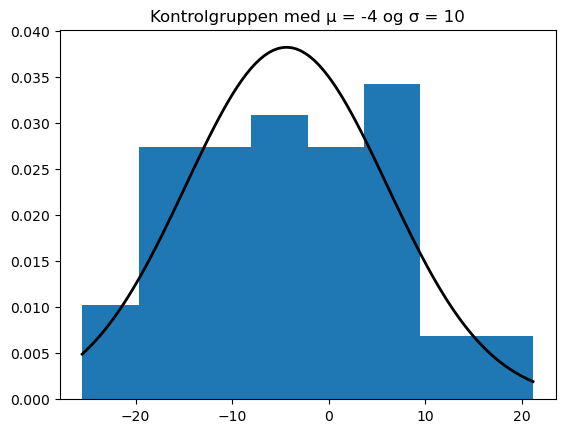

In [23]:

mu, std = scipy.stats.norm.fit(y)
plt.hist(y, bins=8, density=True)
xmin = np.min(y)
xmax = np.max(y)
#xmin, xmax = plt.xlim()
plt.plot(np.linspace(xmin, xmax, 100), scipy.stats.norm.pdf(np.linspace(xmin, xmax, 100), mu, std), 'k', linewidth=2)
title = "Kontrolgruppen med μ = {:.0f} og σ = {:.0f}".format(mu, std)
plt.title(title)

In [24]:
# gjennomsnitt og standardavvik
Ey = np.mean(y)
sigmay = np.std(y)

In [25]:
# antatt gjennomsnitt
mu0 = 0

In [26]:
t_verdi = (Ey - mu0)/(sigmay / np.sqrt(len(y)))

In [27]:
t_verdi

np.float64(-2.9508593017859903)

In [28]:
Ey

np.float64(-4.35994)

In [29]:
# t-verdi og antall frihetsgrader

antall_frihetsgrader = len(y) - 1
float(t_verdi), antall_frihetsgrader

(-2.9508593017859903, 49)

Arealet til det (usynlige) røde området på figuren under er sannsynligheten for at nullhypotesen er sann.

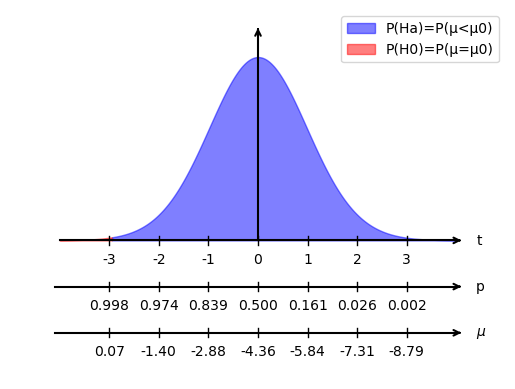

In [36]:
# @title plot

# Define the function
x = np.linspace(-4, 4, 1000)
yy = scipy.stats.t.pdf(x, antall_frihetsgrader)  # t-fordeling med 10 frihetsgrader
t_crit = t_verdi

def mu_av_t(ti):
    return Ey - ti*(sigmay/np.sqrt(len(y)))
# def mu_av_t(m):
#     return (Ey - m)/(sigmay/np.sqrt(len(y)))

ax = plt.gca()


plt.fill_between(x, yy, where=(x > t_crit), color='blue', alpha=0.5, label=r'P(Ha)=P(μ<μ0)')
plt.fill_between(x, yy, where=(x < t_crit), color='red', alpha=0.5, label=r'P(H0)=P(μ=μ0)')
# Remove default spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Set limits
ax.set_xlim(-5, 5)
ax.set_ylim(-.3, .5)  # Ensure axes are visible

# Draw the primary x-axis (for x) with an arrow
ax.plot([-4, 4], [0, 0], color="black", lw=1.5)
ax.annotate("", xy=(4.1, 0), xytext=(4., 0),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
ax.text(4.4, 0, r"t", verticalalignment="center")

# Draw the secondary x-axis (for -x) with an arrow
ax.plot([-4.1, 4], [-.1, -.1], color="black", lw=1.5)
ax.annotate("", xy=(4.1, -.1), xytext=(4., -.1),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
ax.text(4.4, -.1, r"p", verticalalignment="center")

# Draw the third x-axis (for -x) with an arrow
ax.plot([-4.1, 4], [-.2, -.2], color="black", lw=1.5)
ax.annotate("", xy=(4.1, -.2), xytext=(4., -.2),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
ax.text(4.4, -.2, r"$\mu$", verticalalignment="center")

# Draw the y-axis with an arrow
ax.plot([0, 0], [0, .45], color="black", lw=1.5)
ax.annotate("", xy=(0, .46), xytext=(0, .45),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
#ax.text(-0.3, .45, r"y", verticalalignment="center")


# Set x-ticks for t-axis
ticks = np.arange(-3, 4, 1)  # Tick positions

# Draw ticks for t-axis
for ti in ticks:
    ax.plot([ti, ti], [-.01, .01], color="black", lw=1)  # Small tick marks
    ax.text(ti, -.05, f"{ti}", fontsize=10, ha="center")  # Labels below ticks

# Draw ticks for p-axis
for ti in ticks:
    p = scipy.stats.t.cdf(-ti, antall_frihetsgrader)
    ax.plot([ti, ti], [-.11, -.09], color="black", lw=1)  # Small tick marks
    ax.text(ti, -.15, f"{p:.3f}", fontsize=10, ha="center")  # Labels below ticks


# Set ticks for μ-axis
# mu_min = mu_av_t(-3)
# mu_maks = mu_av_t(3)
# mu_verdier = np.linspace(mu_min, mu_maks, endpoint=True, num=7)
# muticks = [t_av_mu(mu) for mu in mu_verdier]
# muticks = [mu_av_t(t) for t in ticks]
# Draw ticks for secondary x-axis (-x)
#for t, mu in zip(muticks, mu_verdier):
for ti in ticks:
    ax.plot([ti, ti], [-.21, -.19], color="black", lw=1)  # Small tick marks
    ax.text(ti, -.25, f"{int(1000*mu_av_t(ti))/1000:2.2f}", fontsize=10, ha="center")  # Labels below ticks

# Remove y-ticks
ax.set_yticks([])
ax.set_xticks([])
plt.legend()
plt.savefig('ttilp.png')
plt.show()

